<p align="center">
  <img src="imagen/image_logo_notebook.png" width="800">
</p>

# Práctica Obligatoria: Regresión Lineal y Regularización


* La práctica obligatoria de esta unidad consiste en hacer un modelado completo de un problema que ya conoces, la predicción de casas, pero con otro dataset. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Modelo de Regresión Lineal

El objetivo del modelo que tienes que construir es predecir la mediana del precio de las casas en una zona del área metropolitana de Boston dadas las características de las mismas. Sí, es parecido pero no igual a lo que hemos venido haciendo.

Aquí tienes una descripción de las variables del dataset, del que tendrás que decidir el target:  

***CRIM:*** Tasa de criminalidad per cápita por ciudad  
***ZN:*** Proporción de terreno residencial destinado a lotes de más de 25,000 pies cuadrados  
***INDUS:*** Proporción de acres de negocios no minoristas por ciudad  
***CHAS:*** Variable ficticia del río Charles (= 1 si el sector limita con el río; 0 en caso contrario)  
***NOX:*** Concentración de óxidos de nitrógeno (partes por 10 millones)  
***RM:*** Número promedio de habitaciones por vivienda  
***AGE:*** Proporción de unidades ocupadas por el propietario construidas antes de 1940  
***DIS:*** Distancias ponderadas a cinco centros de empleo de Boston  
***RAD:*** Índice de accesibilidad a autopistas radiales  
***TAX:*** Tasa de impuesto sobre la propiedad de valor total por $10,000  
***PTRATIO:*** Relación alumno-maestro por ciudad  
***LSTAT:*** % de población de estatus socioeconómico bajo  
***MEDV:*** Valor medio de las viviendas ocupadas por sus propietarios en miles de dólares  

### Indicaciones

A continuación tienes las indicaciones para hacer el modelado. No necesariamente tienes que seguirlos al pie de la letra, porque a partir de ahora ya las práctica obligatorias dejarán de ser mayormente guiadas por ejercicios y serán más de libre desarrollo, aunque con objetivos específicos, claros y determinados. 

En concreto se pide hacer un modelo de regresión lineal, evaluarlo contra un dataset de test reservado del original mostrando MAE,RMSE,MSE y $R2$, comparar las predicciones con los valores reales y realizar al menos un tipo de regularización de las conocidas, testando por lo menos 3 valores diferentes de hiperparámetros.

Los pasos para guiar el trabajo:
1. Carga el dataset. Está limpio y no necesitarás completar nulos, ni repasar los valores de las columnas.
2. Escoge y analiza la variable target de forma gráfica para ver la idoneidad de hacer un modelo de regresión.
3. Haz el split en train y test que creas conveniente y de la forma que creas conveniente.
4. Construye las parejas X,y de train y test
5. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.
6. Trata las variables para que funcionen lo mejor posible en el modelo.
7. Construye un modelo de regresión lineal.
8. Analiza si lo crees conveniente los pesos y la importancia de las features.
8. Evalúa tu modelo. Haz un pequeño assesmente de su generabilidad. Compara gráficamente las predicciones con los valores reales.
9. Regulariza al menos con un modelo alternativo y juega con 3 posibles valores de los hiperparámetros del modelo de regularización.
10. Expresa tus conclusiones, en concreto ¿con qué modelo te quedarías?¿por qué?


In [11]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [12]:
df_boston = pd.read_csv(
    "data/hard_to_find/obligatoria_hard.csv",
    sep="|"
)

df_boston.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


In [13]:
df = df_boston.copy()

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  LSTAT    506 non-null    float64
 12  MEDV     506 non-null    float64
dtypes: float64(13)
memory usage: 51.5 KB


In [15]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


## 1. Análisis de la variable objetivo

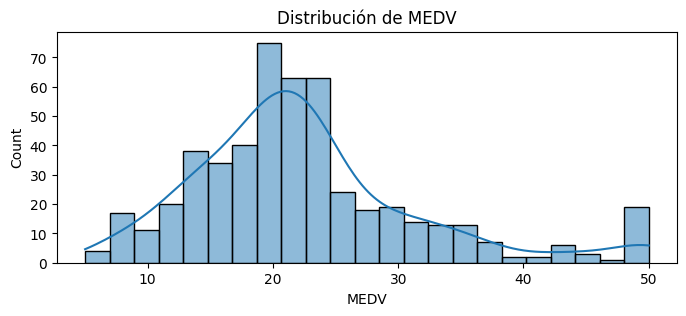

In [16]:
plt.figure(figsize=(8,3))
sns.histplot(df["MEDV"], kde=True)
plt.title("Distribución de MEDV")
plt.show()

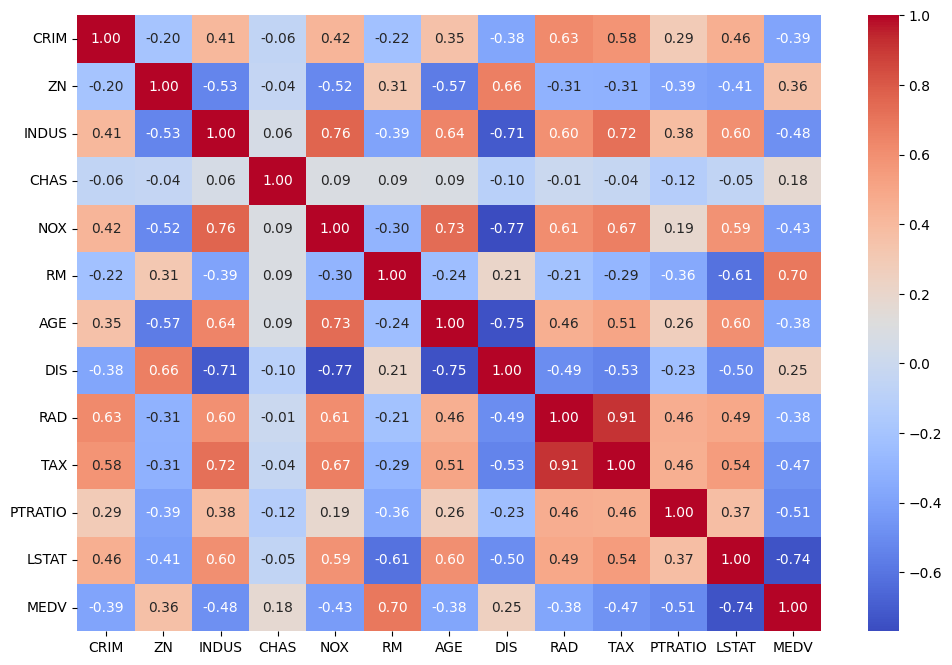

In [17]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()


### Matriz de correlación

In [18]:
corr_medv = df.corr()["MEDV"].sort_values(ascending=False)
print(corr_medv)

MEDV       1.000000
RM         0.695360
ZN         0.360445
DIS        0.249929
CHAS       0.175260
AGE       -0.376955
RAD       -0.381626
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64


In [19]:
# MEDV y LSTAT valores mas altos de correlacion

## 2. Train/Test Split y preparación

In [20]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

print(train_df.shape)
print(test_df.shape)


(404, 13)
(102, 13)


## 3. Ejes X e Y

In [21]:
x_train = train_df.drop("MEDV", axis=1)     ### todas menos MEDV
y_train = train_df["MEDV"]                  ### MEDV

x_test = test_df.drop("MEDV", axis=1)
y_test = test_df["MEDV"]

print(x_train.shape)
print(y_train.shape)

print(x_test.shape)
print(y_test.shape)

(404, 12)
(404,)
(102, 12)
(102,)


## 4. Mini EDA

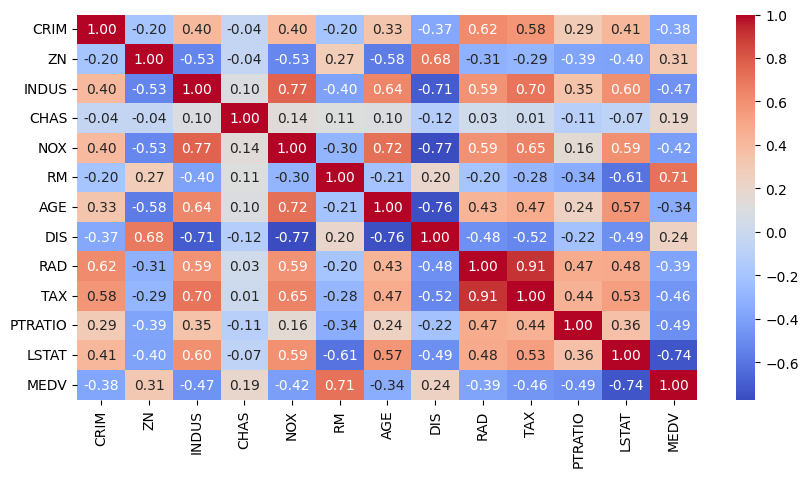

In [22]:
corr_train = train_df.corr()

plt.figure(figsize=(10,5))

sns.heatmap(
    corr_train,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.show()

In [24]:
corr_medv = corr_train["MEDV"].sort_values(ascending=False)

print(corr_medv)

MEDV       1.000000
RM         0.710680
ZN         0.309504
DIS        0.235114
CHAS       0.190642
AGE       -0.340216
CRIM      -0.380091
RAD       -0.387467
NOX       -0.415768
TAX       -0.459795
INDUS     -0.470546
PTRATIO   -0.491210
LSTAT     -0.736422
Name: MEDV, dtype: float64


In [25]:
for col in train_df.columns:
    print(train_df[col].value_counts())
    print("--------------------")

CRIM
0.01501     2
15.02340    1
0.62739     1
0.03466     1
7.05042     1
           ..
0.15876     1
0.17120     1
0.29916     1
11.16040    1
0.22876     1
Name: count, Length: 403, dtype: int64
--------------------
ZN
0.0      294
20.0      18
80.0      11
22.0       9
25.0       8
30.0       6
12.5       6
45.0       6
40.0       5
90.0       4
21.0       4
35.0       3
60.0       3
70.0       3
33.0       3
34.0       3
52.5       3
55.0       3
85.0       2
28.0       2
95.0       2
82.5       2
75.0       2
100.0      1
17.5       1
Name: count, dtype: int64
--------------------
INDUS
18.10    101
19.58     29
8.14      18
6.20      16
3.97      11
        ... 
7.07       1
4.39       1
4.00       1
10.81      1
2.01       1
Name: count, Length: 72, dtype: int64
--------------------
CHAS
0.0    375
1.0     29
Name: count, dtype: int64
--------------------
NOX
0.5380    18
0.8710    15
0.6050    14
0.7130    13
0.4370    12
          ..
0.3940     1
0.5750     1
0.4161     1
0.4

In [26]:
features = [col for col in df.columns if col not in ["MEDV", "CHAS", "DIS"]]
target = train_df["MEDV"]  

criterio_col = 0.7
excluidas = []
corr_numeric = train_df[features].corr(numeric_only=True)

for col in features:
    print(f"Comprobando colinealidad de {col}")
    if col not in excluidas:
        for col_2, valor_corr in corr_numeric[col].items():
            if col != col_2 and abs(valor_corr) > criterio_col and col_2 not in excluidas:
                print(f"\t{col} y {col_2} tienen correlación alta: {valor_corr:.2f} → eliminando {col_2}")
                excluidas.append(col_2)
    elif col in excluidas:
        print(f"\t{col} ya estaba excluida, se omite")

print("\nVariables excluidas por colinealidad:", excluidas)

features_sin_col = [col for col in features if col not in excluidas]
print("Features finales:", features_sin_col)

Comprobando colinealidad de CRIM
Comprobando colinealidad de ZN
Comprobando colinealidad de INDUS
	INDUS y NOX tienen correlación alta: 0.77 → eliminando NOX
	INDUS y TAX tienen correlación alta: 0.70 → eliminando TAX
Comprobando colinealidad de NOX
	NOX ya estaba excluida, se omite
Comprobando colinealidad de RM
Comprobando colinealidad de AGE
Comprobando colinealidad de RAD
Comprobando colinealidad de TAX
	TAX ya estaba excluida, se omite
Comprobando colinealidad de PTRATIO
Comprobando colinealidad de LSTAT

Variables excluidas por colinealidad: ['NOX', 'TAX']
Features finales: ['CRIM', 'ZN', 'INDUS', 'RM', 'AGE', 'RAD', 'PTRATIO', 'LSTAT']


In [ ]:
for col in excluidas:
    if col in features:
        features.remove(col)

print("Features finales:", features)

Features finales: ['CRIM', 'ZN', 'INDUS', 'RM', 'AGE', 'RAD', 'PTRATIO', 'LSTAT']


In [34]:
x_train = train_df[features]
x_test = test_df[features]

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

## Modelo de Regresión Lineal

In [36]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(x_train_scaled, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [37]:
y_pred = lr.predict(x_test_scaled)

## Importancia de variables

In [38]:
coef_df = pd.DataFrame({
    "Feature": features,
    "Coeficiente": lr.coef_
})

coef_df.sort_values(
    by="Coeficiente",
    ascending=False
)

,Feature,Coeficiente
3,RM,3.421019
4,AGE,0.420812
5,RAD,0.382053
2,INDUS,-0.132904
1,ZN,-0.382906
0,CRIM,-0.957759
6,PTRATIO,-2.023453
7,LSTAT,-4.138256


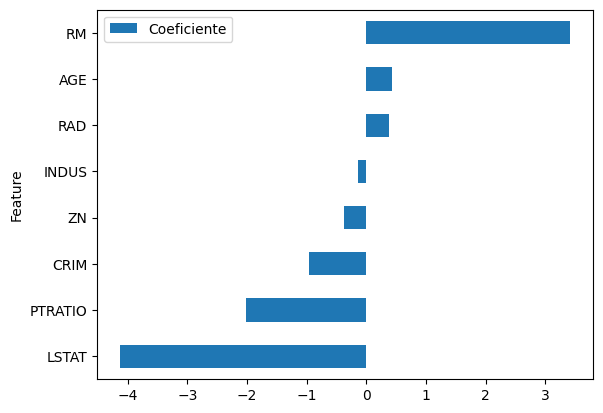

In [39]:
coef_df.sort_values("Coeficiente").plot(
    x="Feature",
    y="Coeficiente",
    kind="barh"
)
plt.show()

## Comparación predicciones vs valores reales

In [40]:
y_pred = lr.predict(x_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.3f}")
print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")

MAE: 3.429
MSE: 28.439
RMSE: 5.333
R²: 0.612


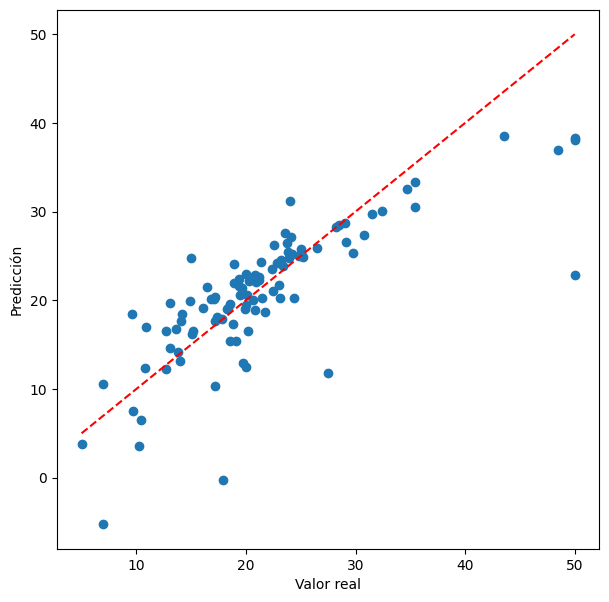

In [41]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred)

plt.xlabel("Valor real")
plt.ylabel("Predicción")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.show()

In [42]:
print("Train R²:", lr.score(x_train_scaled, y_train))
print("Test R²:", lr.score(x_test_scaled, y_test))

Train R²: 0.696260269195818
Test R²: 0.6122030141049813


## 6. Regularización Ridge

In [43]:
alphas = [0.1, 1, 10]

resultados = []

for alpha in alphas:

    ridge = Ridge(alpha=alpha)

    ridge.fit(x_train_scaled, y_train)

    pred = ridge.predict(x_test_scaled)

    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)

    resultados.append(
        [alpha, mae, mse, rmse, r2]
    )

ridge_results = pd.DataFrame(
    resultados,
    columns=["alpha", "MAE", "MSE", "RMSE", "R2"]
)

ridge_results

,alpha,MAE,MSE,RMSE,R2
0,0.1,3.428888,28.436583,5.332596,0.612231
1,1.0,3.427065,28.418383,5.330890,0.612479
2,10.0,3.409482,28.249046,5.314983,0.614788


## Conclusiones

- En una primera iteración, se construyó un modelo de regresión lineal utilizando
únicamente las variables RM, LSTAT y PTRATIO, seleccionadas por presentar las
mayores correlaciones con la variable objetivo (MEDV). Este modelo obtuvo un
R² = 0.63, explicando el 63% de la variabilidad del precio de las viviendas.

- En una segunda iteración, se amplió el conjunto de predictores incorporando
todas las variables disponibles del dataset, lo que elevó el R² a 0.68,
confirmando que las variables descartadas en el análisis de correlación
también aportaban información relevante para la predicción.

- Sin embargo, el análisis de los coeficientes del modelo reveló indicios de
multicolinealidad. Se excluyo CHAS por su escasa varianza al tratarse de una
variable binaria con muy pocos casos positivos, y DIS por su contribución
marginal al modelo.

- Se reentrenó el modelo obteniendo las siguientes métricas sobre el conjunto de test:

    * MAE = 3.429
    * MSE = 28.439
    * RMSE = 5.333
    * R² = 0.612

- Se aplicó regularización mediante Ridge Regression, probando α = 0.1, 1 y 10,
obteniendo los siguientes resultados:

    | α   | MAE   | MSE    | RMSE  | R²    |
    |-----|-------|--------|-------|-------|
    | 0.1 | 3.429 | 28.437 | 5.333 | 0.612 |
    | 1.0 | 3.427 | 28.418 | 5.331 | 0.612 |
    | 10  | 3.409 | 28.249 | 5.315 | 0.614 |

- Ridge con α = 10 obtuvo el mejor resultado, el modelo no presenta sobreajuste
significativo tras la depuración de variables.

- Se seleccionó Ridge con α = 10 como modelo final por ofrecer el
mejor equilibrio entre rendimiento predictivo y estabilidad de coeficientes.
La eliminación de CHAS y DIS penalizó ligeramente el R² respecto al modelo con todas las variables (0.68 → 0.612).